## Plots for the technical report 

This notebook contains all the plots for the technical report. This notebook utilises almost all the code I wrote over the summer

In [18]:
import os as os
import sys
import numpy as np

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)
import matplotlib.pyplot as plt
from psd_estimation_methods.wosa import wosa
from psd_estimation_methods.lpsd import lpsd
from psd_estimation_methods.logpsd import logpsd
from scripts.readTdi import readTdi, getTdiPath
from scripts.plot import plot_psd_noise_histogram_two_cross_two 
from scripts.psdNoise import n_noise_psds, compute_psd_noise_distribution, n_time_noise_from_psd
from scipy.stats import chi2
from scripts.pdf import median_pdf
from scripts.pdf import pdf


from matplotlib.ticker import LogFormatter
from matplotlib.ticker import ScalarFormatter
from matplotlib.lines import Line2D


In [19]:
plt.rcParams.update({
    "text.usetex": False,          # avoid LaTeX entirely
    "font.family": "Arial",        
    "font.sans-serif": ["Arial"],
    "mathtext.fontset": "dejavusans",    # match math to text
    "axes.titlesize": 18,
    "axes.titleweight": "normal",
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.dpi": 150,
})

econ_chicago_45 = '#2E45B8'
econ_chicago_90 = '#D6DBF5'
econ_singapore_55 = '#F97A1F'
econ_tokyo_45 = '#C91D42'
econ_LA_90 = '#EBE9E0'
econ_paris_95 = "#EFF5F5"
econ_red = "#E3120B"

In [20]:
tdi_path = getTdiPath('vsmall_glitch_long_tdi.h5')
data, fs, t = readTdi(tdi_path)

We compare three PSD estimation methods (WOSA, LPSD, and LogPSD). The estimates differ noticeably in regions where the true PSD changes rapidly, since each method uses a different frequency resolution.

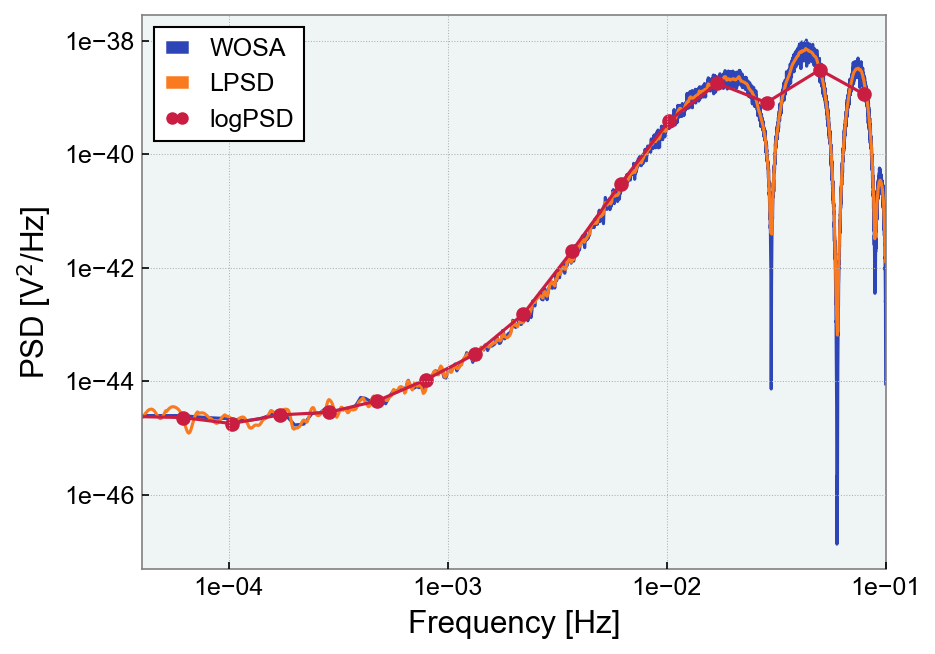

In [21]:
# curves should have econ_chicago_45 color 
# For each axes:
# ax.xaxis.set_major_formatter(LogFormatter(base=10))
# ax.yaxis.set_major_formatter(LogFormatter(base=10))
# ax.legend(facecolor=econ_paris_95,
#           edgecolor="black",
#           framealpha=1)
# ax.tick_params(direction="in")

f_wosa, psd_wosa, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=10000
) 
f_lpsd, psd_lpsd, _, _ = lpsd(
    x=data,
    fs=fs
) 
f_logpsd, psd_logpsd, _ = logpsd(x=data, fs=fs, overlap=0, L1=100000)
f_nyq = fs/2    
fig, ax = plt.subplots()
ax.plot(f_wosa,  psd_wosa,       label='WOSA', color=econ_chicago_45)                 
ax.plot(f_lpsd,  psd_lpsd,       label='LPSD', color=econ_singapore_55)                
ax.plot(f_logpsd, psd_logpsd, 'o-', label='logPSD', color=econ_tokyo_45) 


#––– cosmetics ––––––––––––––––––––––––––––––––––––––––––––––––
ax.set_xlim(fs/5000, f_nyq)               # 0 → Nyquist on the x-axis
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel(r"PSD [V$^2$/Hz]")
ax.set_xscale('log')
ax.set_yscale('log')

ax.grid(True, which='both', ls=':', lw=0.5)
ax.xaxis.set_major_formatter(LogFormatter(base=10))
ax.yaxis.set_major_formatter(LogFormatter(base=10))
ax.set_facecolor(econ_paris_95)
#fig.patch.set_facecolor(econ_paris_95)


custom_lines = [
    Line2D([0], [0], color=econ_chicago_45, lw=2),                   # WOSA
    Line2D([0], [0], color=econ_singapore_55, lw=2),                   # LPSD
    Line2D([0], [0], color=econ_tokyo_45, marker="o", linestyle="", markersize=5, lw=0.1) # logPSD: dot only
]

# ax.legend(custom_lines, ["WOSA", "LPSD", "logPSD"],
#           facecolor=econ_paris_95,
#           edgecolor="black",
#           framealpha=1)
ax.legend(custom_lines, ["WOSA", "LPSD", "logPSD"],
          edgecolor="black",
          framealpha=1)
ax.tick_params(direction="in")
ax.minorticks_off()
plt.savefig("../report_figs/01_wosa_lpsd_logpsd.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

In [22]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_1.h5')
data_orig, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


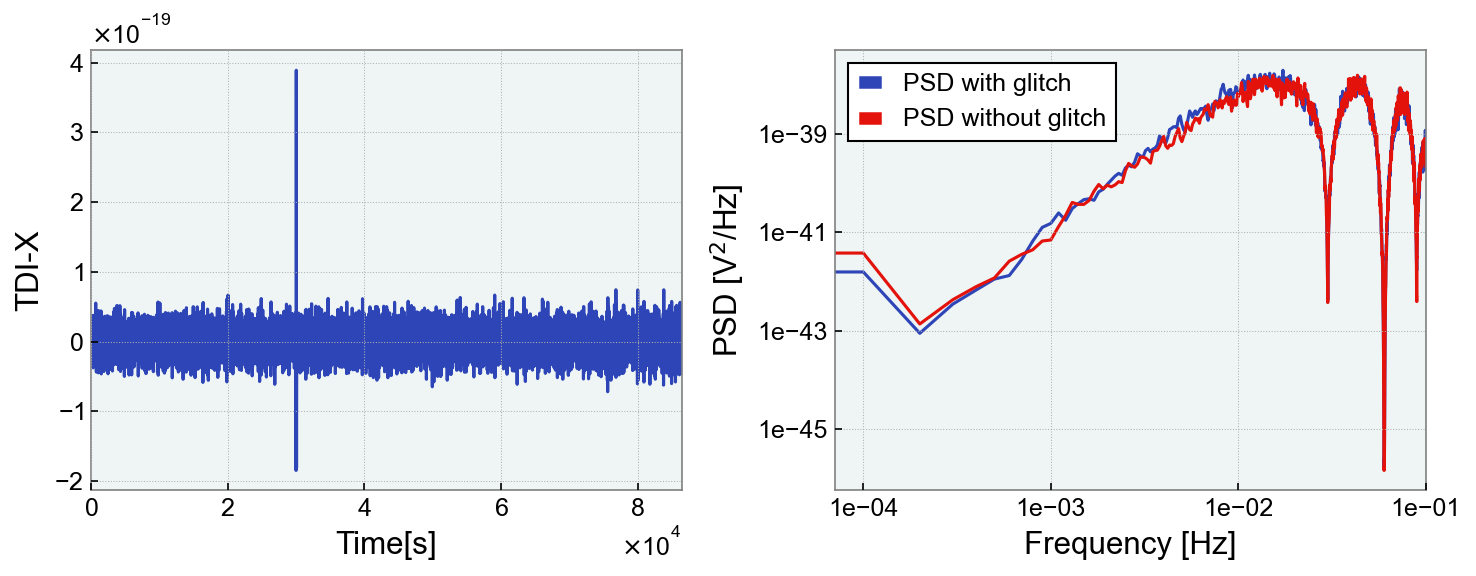

In [23]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_0.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# Layout: time series + PSD
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ----- (1) Time-domain plot -----
ax0 = axes[0]
ax0.plot(t, data, color=econ_chicago_45)
ax0.set_xlim(t[0], t[-1])
ax0.set_xlabel("Time[s]")
ax0.set_ylabel("TDI-X")

# ----- (2) PSD(s) -----
ax1 = axes[1]

# PSD with glitch
ax1.loglog(f_mean, psd_mean, label="PSD with glitch", color=econ_chicago_45)

# PSD without glitch
ax1.loglog(f_mean, psd_orig, label="PSD without glitch", color=econ_red)

# Frequency limits from f_lims = [f_mean[0], f_mean[-1]]
ax1.set_xlim(f_mean[0], f_mean[-1])

ax1.set_xlabel("Frequency [Hz]")
ax1.set_ylabel(r"PSD [V$^2$/Hz]")

#
ax0.tick_params(direction="in")
ax0.set_facecolor(econ_paris_95)

# ax1.legend(facecolor=econ_paris_95,
#           edgecolor="black",
#           framealpha=1)
ax1.legend(edgecolor="black",
          framealpha=1)
ax1.set_facecolor(econ_paris_95)
ax1.tick_params(direction="in")
ax1.xaxis.set_major_formatter(LogFormatter(base=10))
ax1.yaxis.set_major_formatter(LogFormatter(base=10))
ax1.minorticks_off()
ax0.grid(True, which='both', ls=':', lw=0.5)
ax1.grid(True, which='both', ls=':', lw=0.5)
##fig.patch.set_facecolor(econ_paris_95)

fig.tight_layout()
plt.savefig("../report_figs/02_wosa_small_glitch.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


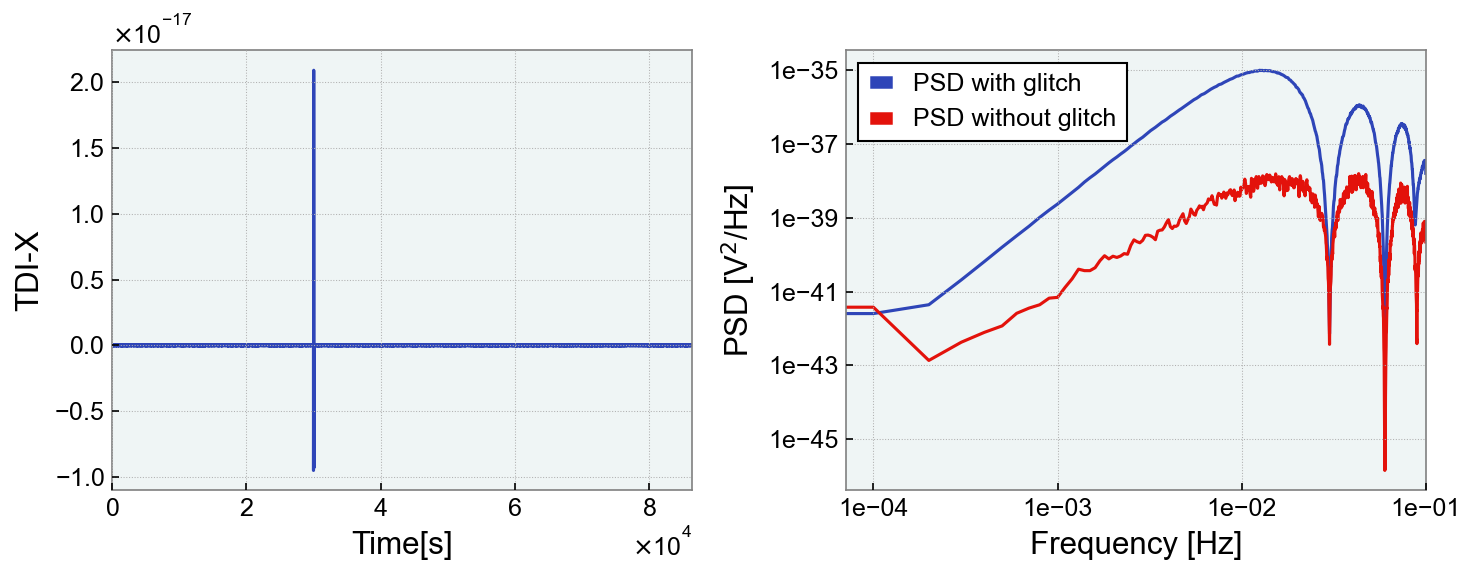

In [24]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_7.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# Layout: time series + PSD
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ----- (1) Time-domain plot -----
ax0 = axes[0]
ax0.plot(t, data, color=econ_chicago_45)
ax0.set_xlim(t[0], t[-1])
ax0.set_xlabel("Time[s]")
ax0.set_ylabel("TDI-X")

# ----- (2) PSD(s) -----
ax1 = axes[1]

# PSD with glitch
ax1.loglog(f_mean, psd_mean, label="PSD with glitch", color=econ_chicago_45)

# PSD without glitch
ax1.loglog(f_mean, psd_orig, label="PSD without glitch", color=econ_red)

# Frequency limits from f_lims = [f_mean[0], f_mean[-1]]
ax1.set_xlim(f_mean[0], f_mean[-1])

ax1.set_xlabel("Frequency [Hz]")
ax1.set_ylabel(r"PSD [V$^2$/Hz]")

#
ax0.tick_params(direction="in")
ax0.set_facecolor(econ_paris_95)

# ax1.legend(facecolor=econ_paris_95,
#           edgecolor="black",
#           framealpha=1)
ax1.legend(
          edgecolor="black",
          framealpha=1)
ax1.set_facecolor(econ_paris_95)
ax1.tick_params(direction="in")
ax1.xaxis.set_major_formatter(LogFormatter(base=10))
ax1.yaxis.set_major_formatter(LogFormatter(base=10))
ax1.minorticks_off()
#fig.patch.set_facecolor(econ_paris_95)
ax0.grid(True, which='both', ls=':', lw=0.5)
ax1.grid(True, which='both', ls=':', lw=0.5)

fig.tight_layout()
plt.savefig("../report_figs/03_wosa_med_glitch.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


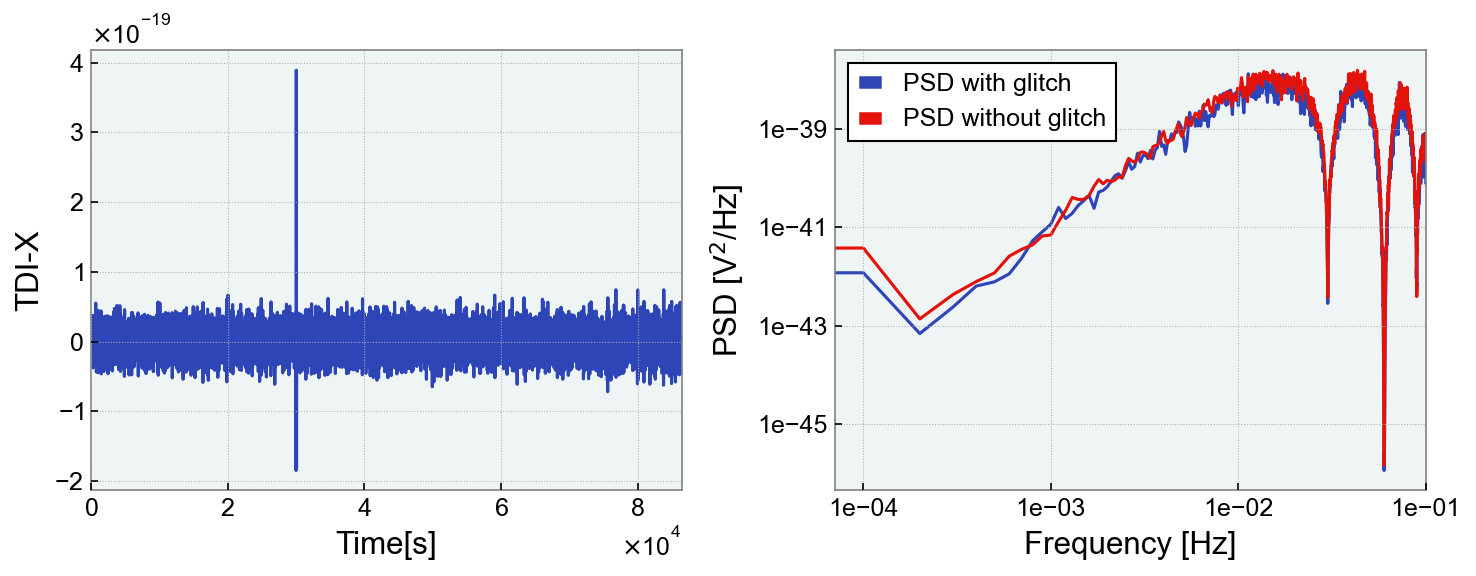

In [25]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_0.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# Layout: time series + PSD
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ----- (1) Time-domain plot -----
ax0 = axes[0]
ax0.plot(t, data, color=econ_chicago_45)
ax0.set_xlim(t[0], t[-1])
ax0.set_xlabel("Time[s]")
ax0.set_ylabel("TDI-X")

# ----- (2) PSD(s) -----
ax1 = axes[1]

# PSD with glitch
ax1.loglog(f_median, psd_median, label="PSD with glitch", color=econ_chicago_45)

# PSD without glitch
ax1.loglog(f_mean, psd_orig, label="PSD without glitch", color=econ_red)

# Frequency limits from f_lims = [f_mean[0], f_mean[-1]]
ax1.set_xlim(f_median[0], f_median[-1])

ax1.set_xlabel("Frequency [Hz]")
ax1.set_ylabel(r"PSD [V$^2$/Hz]")

#
ax0.tick_params(direction="in")

# ax1.legend(facecolor=econ_paris_95,
#           edgecolor="black",
#           framealpha=1)
ax1.legend(
          edgecolor="black",
          framealpha=1)

ax1.tick_params(direction="in")
ax1.xaxis.set_major_formatter(LogFormatter(base=10))
ax1.yaxis.set_major_formatter(LogFormatter(base=10))
ax1.minorticks_off()
ax0.grid(True, which='both', ls=':', lw=0.5)
ax1.grid(True, which='both', ls=':', lw=0.5)

#fig.patch.set_facecolor(econ_paris_95)
ax0.set_facecolor(econ_paris_95)
ax1.set_facecolor(econ_paris_95)

fig.tight_layout()
plt.savefig("../report_figs/04_wosa_median_small_glitch.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


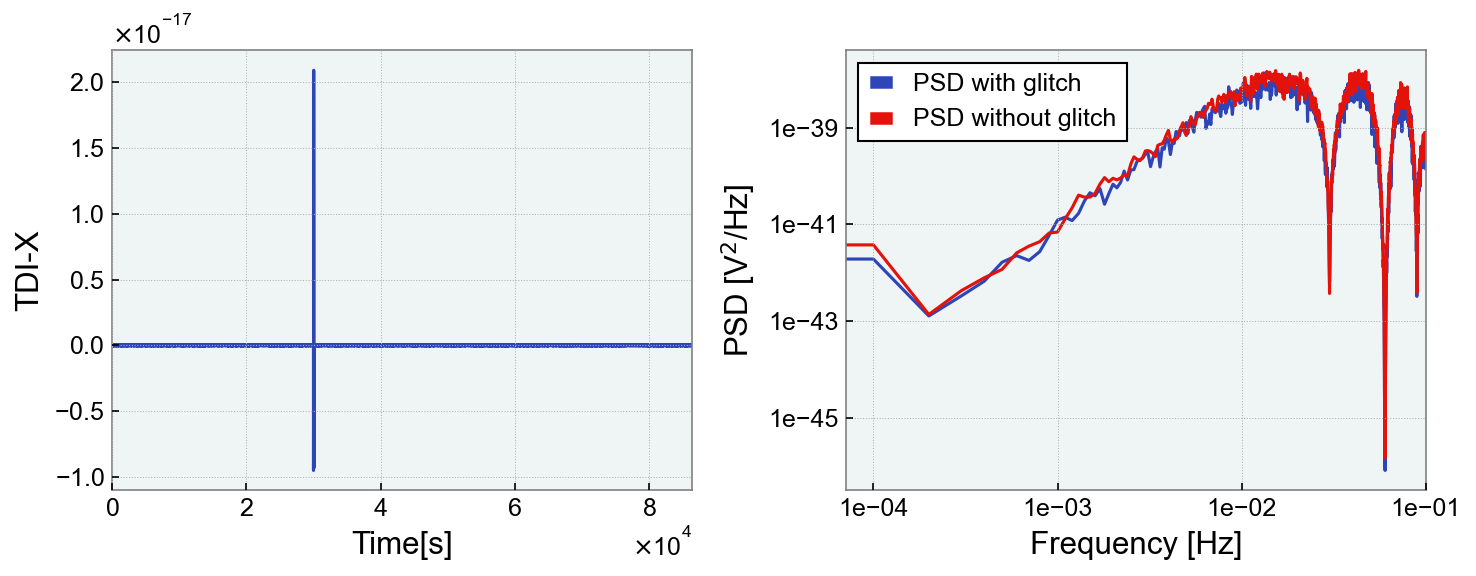

In [26]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_7.h5')
data, fs, t = readTdi(tdi_path)



# 2) Find the PSD of TDI time series
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# Layout: time series + PSD
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ----- (1) Time-domain plot -----
ax0 = axes[0]
ax0.plot(t, data, color=econ_chicago_45)
ax0.set_xlim(t[0], t[-1])
ax0.set_xlabel("Time[s]")
ax0.set_ylabel("TDI-X")

# ----- (2) PSD(s) -----
ax1 = axes[1]

# PSD with glitch
ax1.loglog(f_median, psd_median, label="PSD with glitch", color=econ_chicago_45)

# PSD without glitch
ax1.loglog(f_mean, psd_orig, label="PSD without glitch", color=econ_red)

# Frequency limits from f_lims = [f_mean[0], f_mean[-1]]
ax1.set_xlim(f_median[0], f_median[-1])

ax1.set_xlabel("Frequency [Hz]")
ax1.set_ylabel(r"PSD [V$^2$/Hz]")

#
ax0.tick_params(direction="in")


# ax1.legend(facecolor=econ_paris_95,
#           edgecolor="black",
#           framealpha=1)
ax1.legend(
          edgecolor="black",
          framealpha=1)

ax1.tick_params(direction="in")
ax1.xaxis.set_major_formatter(LogFormatter(base=10))
ax1.yaxis.set_major_formatter(LogFormatter(base=10))
ax1.minorticks_off()
ax0.grid(True, which='both', ls=':', lw=0.5)
ax1.grid(True, which='both', ls=':', lw=0.5)

ax0.set_facecolor(econ_paris_95)
ax1.set_facecolor(econ_paris_95)
#fig.patch.set_facecolor(econ_paris_95)

fig.tight_layout()
plt.savefig("../report_figs/05_wosa_median_medium_glitch.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

1
2
4
8


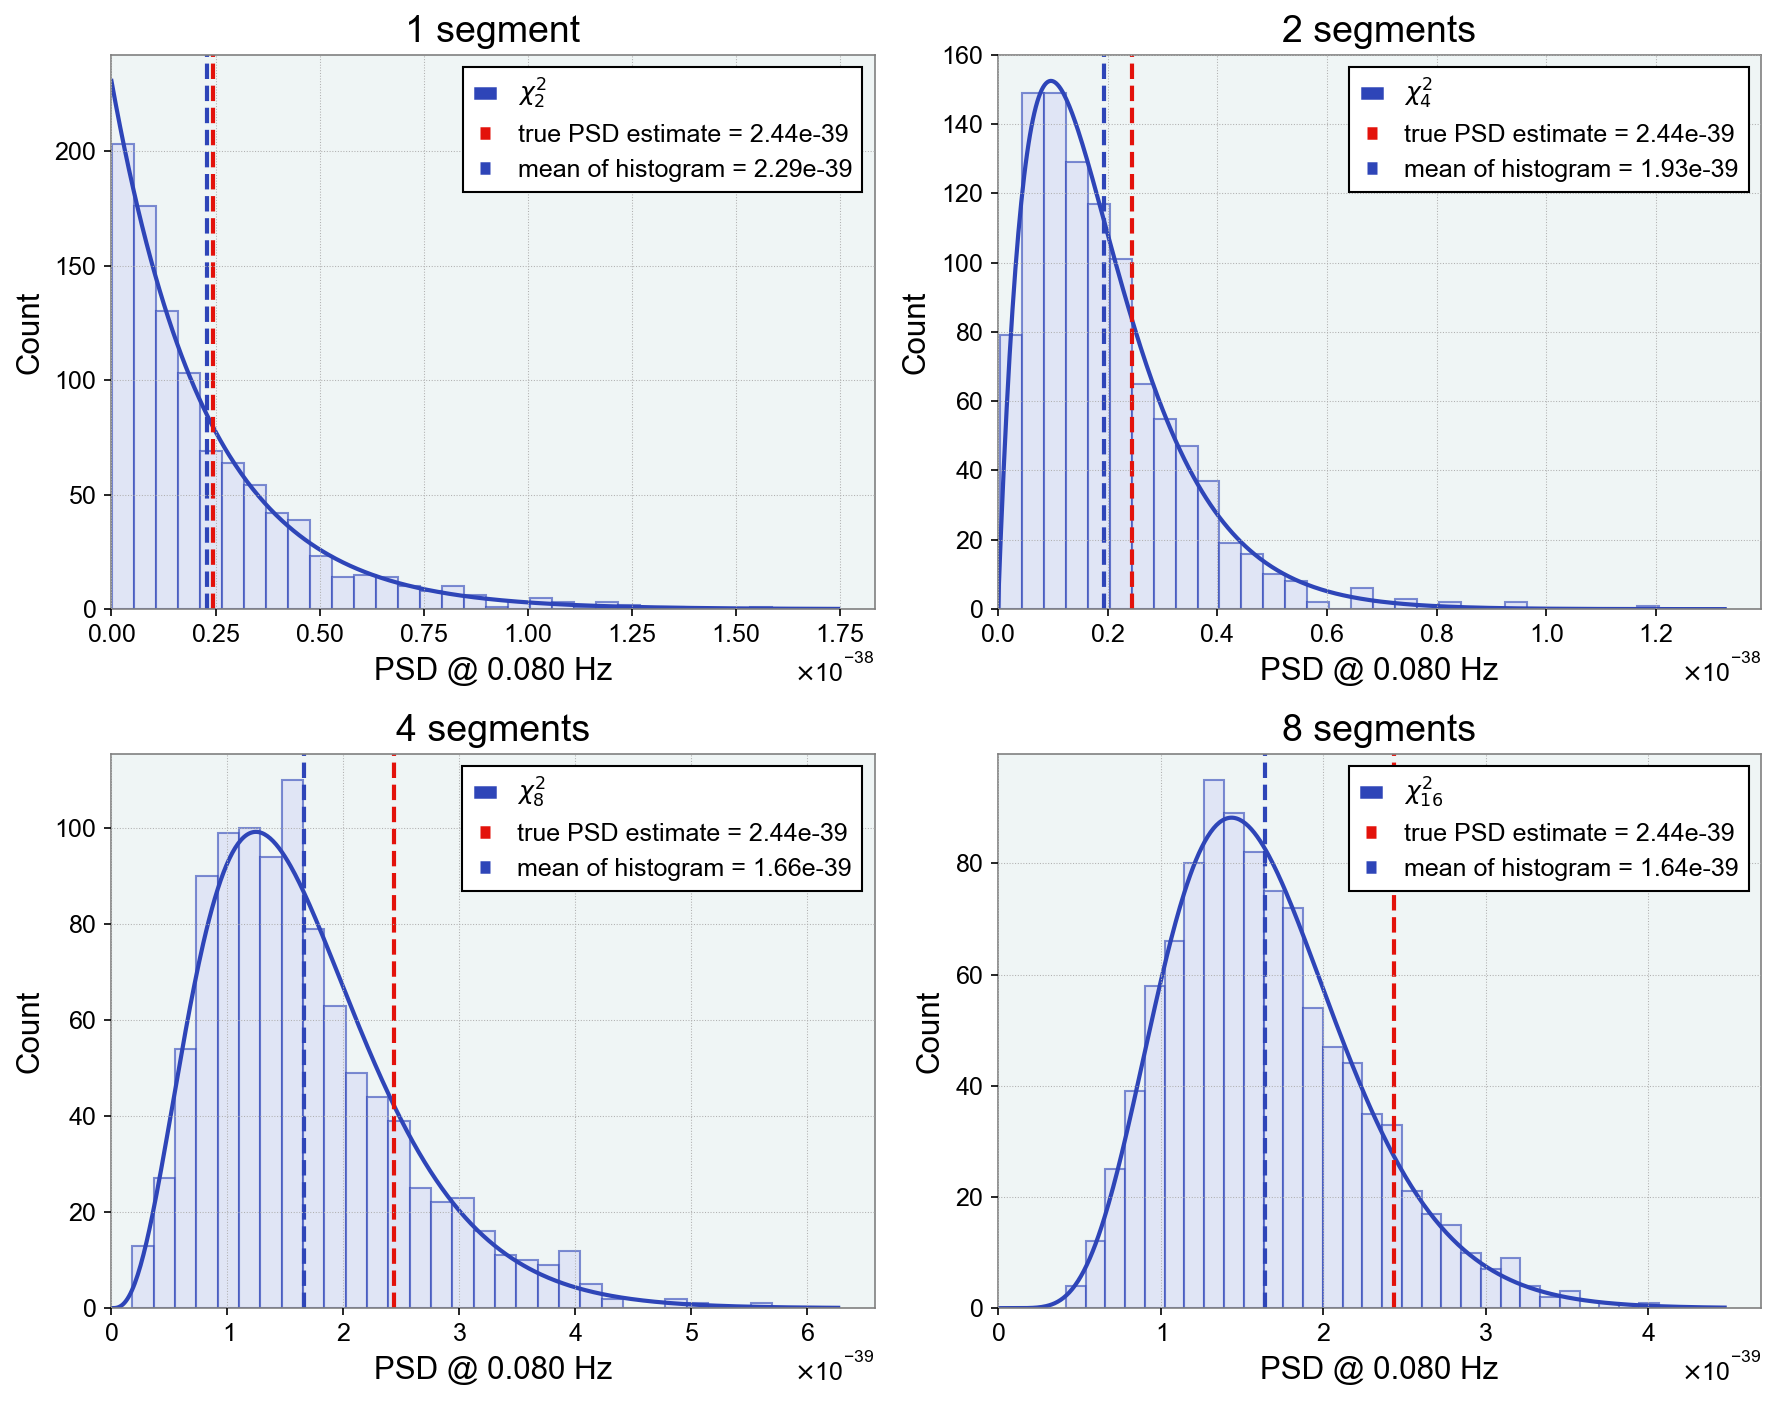

In [27]:
tdi_path = getTdiPath('vsmall_glitch_long_tdi.h5')
data_orig, fs, t = readTdi(tdi_path)

nperseg = 20000
noverlap = 0
fraction=0.8

f_orig, orig_psd, _, nseg = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg
) 

time_noises = n_time_noise_from_psd(
    orig_psd, 
    fs, 
    nperseg, 
    n=1000,
    seed_offset=0
)

nperseg_list = [20000, 10000, 5000, 2500]
noise_vals_list = []
orig_psd_list   = []
freq_list       = []
df_list         = []
seg_counts      = []

for nperseg in nperseg_list:
    f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg, noverlap=noverlap)
    psd_vals, orig_val, chosen_freq, _ = compute_psd_noise_distribution(
        orig_psd, f_orig, noise_psds, f_noise, fraction=fraction
    )
    noise_vals_list.append(psd_vals)
    orig_psd_list.append(orig_val)
    freq_list.append(chosen_freq)
    df_list.append(2 * nseg[0])
    seg_counts.append(nseg[0])
    print(nseg[0])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, noise_vals, orig_psd, freq, df, seg in zip(
    axes.flatten(),
    noise_vals_list,
    orig_psd_list,
    freq_list,
    df_list,
    seg_counts
):
    # histogram
    counts, bins, _ = ax.hist(
        noise_vals, bins=30, density=False, alpha=0.6, edgecolor=econ_chicago_45, color=econ_chicago_90
    )
    bin_width = bins[1] - bins[0]
    total = len(noise_vals)
    x = np.linspace(0, noise_vals.max() * 1.1, 500)

    mean_psd = noise_vals.mean()
    pdf2 = (df/mean_psd) * chi2.pdf(df * x / mean_psd, df)
    ax.plot(x, pdf2 * total * bin_width,
             color=econ_chicago_45, 
             ls = '-',
             lw=2,
            label=rf"$\chi^2_{{{df}}}$")

    # vertical markers
    ax.axvline(orig_psd, color=econ_red, lw=2, ls='--',
               label=f"true PSD estimate = {orig_psd:.2e}")
    # ax.axvline(orig_psd, color='b', lw=2, ls='--',
    #            label=fr"$\mathrm{{PSD}}^{{\mathrm{{true}}}}$ = {orig_psd:.2e}")
    ax.axvline(mean_psd, color=econ_chicago_45, lw=2, ls='--',
               label=f"mean of histogram = {mean_psd:.2e}")

    # labels & title
    ax.set_facecolor(econ_paris_95)
    ax.set_xlabel(f"PSD @ {freq:.3f} Hz")
    ax.set_ylabel("Count")
    ax.set_xlim(left=0)
    title_text = f"{seg} segment" if seg == 1 else f"{seg} segments"
    ax.set_title(title_text)
    # ax.legend(fontsize='small')
    # ax.legend(facecolor=econ_paris_95,
    #       edgecolor="black",
    #       framealpha=1)
    ax.legend(
          edgecolor="black",
          framealpha=1)
    ax.grid(True, which='both', ls=':', lw=0.5)
    
#fig.patch.set_facecolor(econ_paris_95)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../report_figs/06_histogram_wosa_8_hist.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()


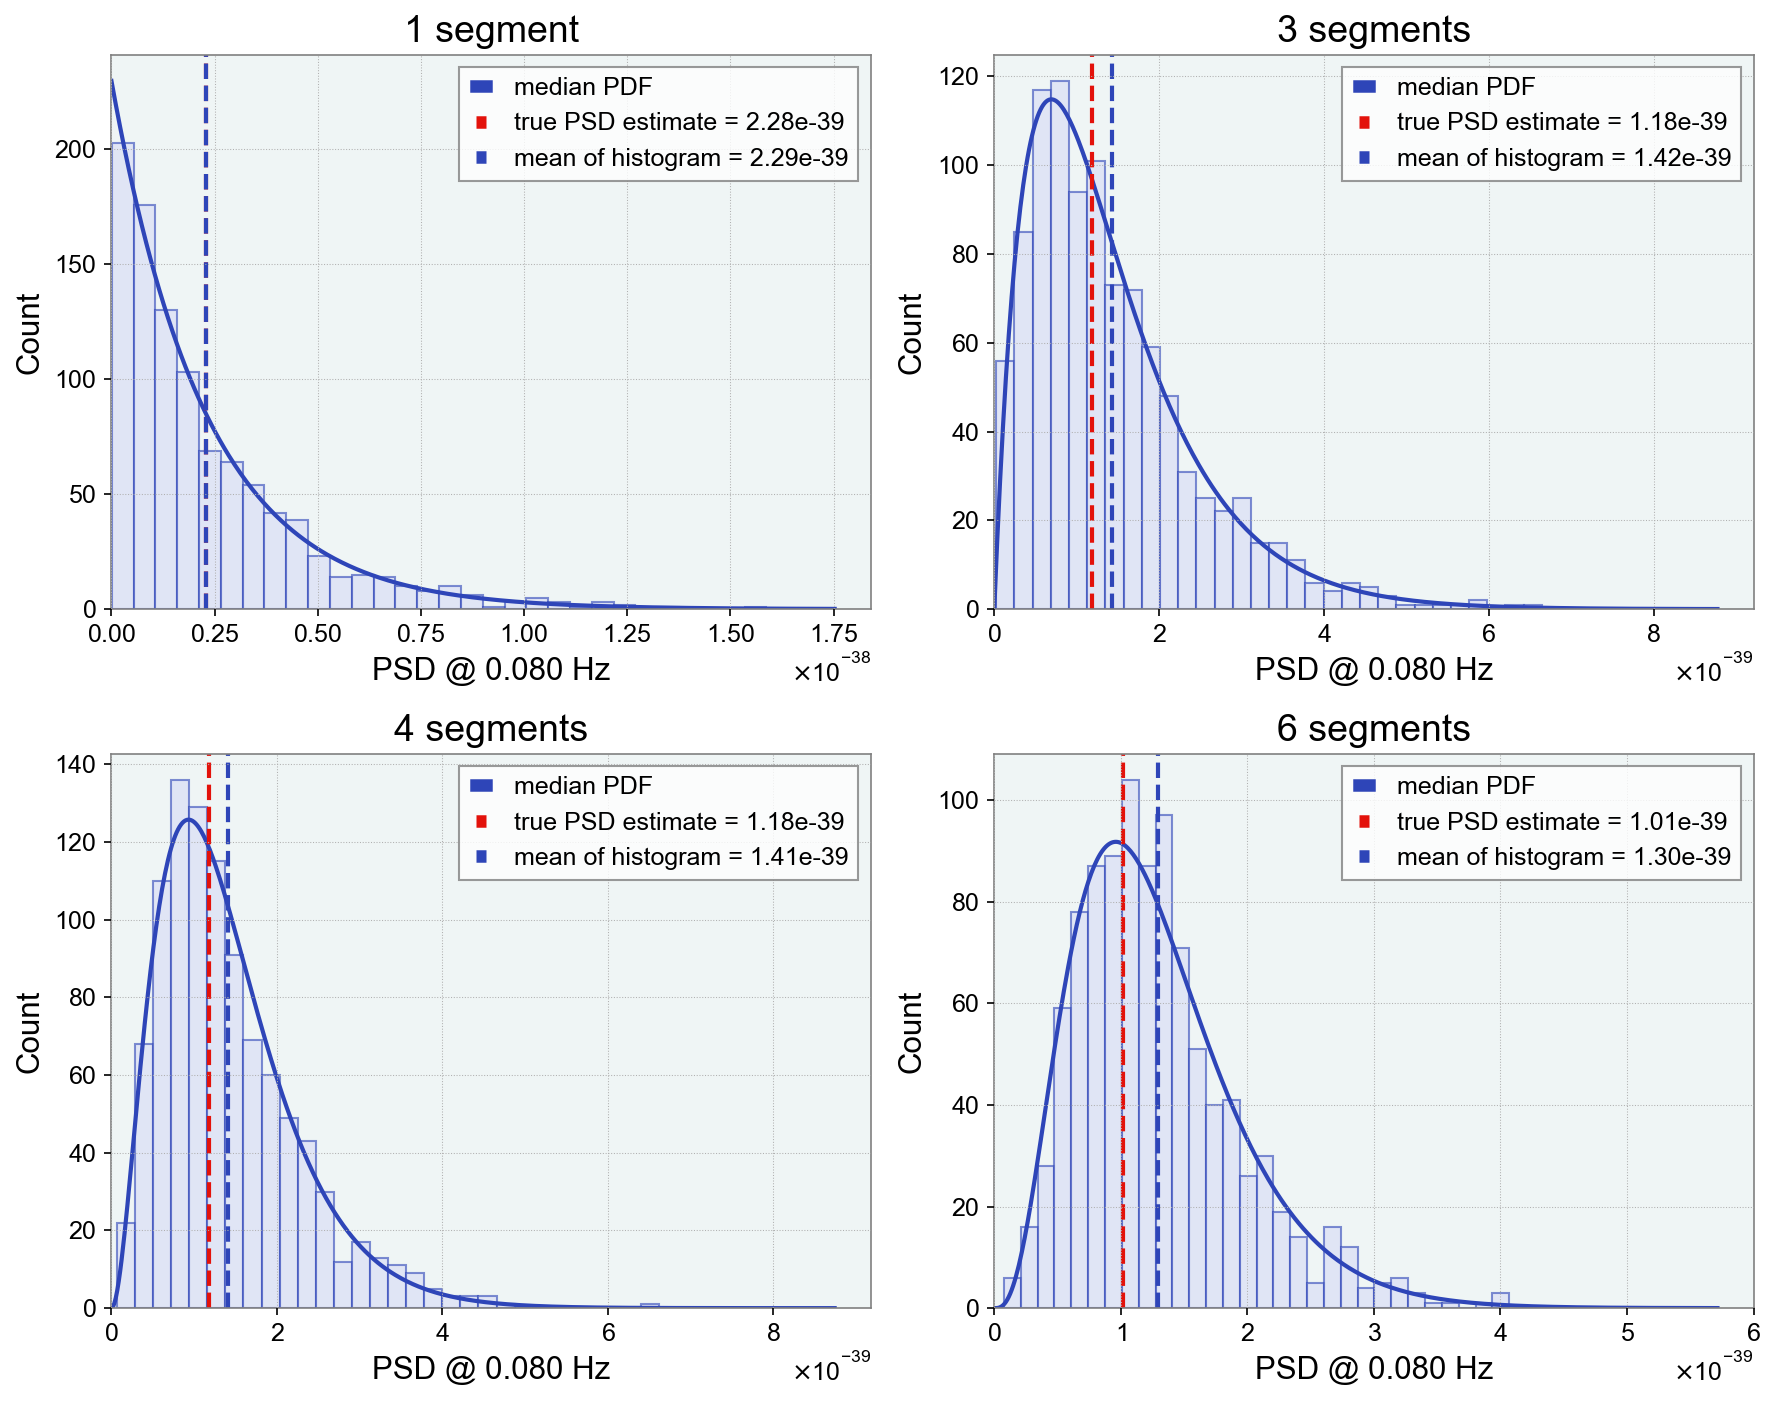

In [28]:
tdi_path = getTdiPath('vsmall_glitch_long_tdi.h5')
data_orig, fs, t = readTdi(tdi_path)

nperseg = 20000
noverlap = 0
fraction=0.8

f_orig, orig_psd, _, nseg = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg
) 


nperseg_list = [20000, 6000, 5000, 3000]
noise_vals_list = []
orig_psd_list   = []
freq_list       = []
df_list         = []
seg_counts      = []

for nperseg in nperseg_list:
    f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg, noverlap=noverlap, method='median')
    psd_vals, orig_val, chosen_freq, _ = compute_psd_noise_distribution(
        orig_psd, f_orig, noise_psds, f_noise, fraction=fraction
    )
    noise_vals_list.append(psd_vals)
    orig_psd_list.append(orig_val)
    freq_list.append(chosen_freq)
    df_list.append(2 * nseg[0])
    seg_counts.append(nseg[0])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, psd_vals, freq, N, seg in zip(
    axes.flatten(),
    noise_vals_list,
    freq_list,
    nperseg_list,
    seg_counts
):
    # 1) Histogram as raw counts
    counts, bins, _ = ax.hist(
        psd_vals,
        bins=30,
        density=False,
        alpha=0.6,
        edgecolor=econ_chicago_45,
        color=econ_chicago_90
    )
    total     = len(psd_vals)
    bin_width = bins[1] - bins[0]
    
    # 2) Build the two model-median PDFs
    x0 = np.linspace(0, psd_vals.max() * 1.1, 500)
    s  = psd_vals.mean()
    
    # a) biased (uncentered)
    pdf0 = median_pdf(x0, seg, s)
    pdf0 /= np.trapz(pdf0, x0)
    
    # b) aligned (centered at histogram mean)
    model_mean0 = np.trapz(x0 * pdf0, x0)
    scale = s / model_mean0
    x1    = x0 * scale
    pdf1  = pdf0 / scale
    
    # 3) Plot model curves scaled to histogram counts
    # (here show_biased_hist=False → only red curve)
    ax.plot(
        x1, pdf1 * total * bin_width,
        ls='-',
        color=econ_chicago_45,
        lw=2,
        label="median PDF"
    )
    
    # 4) Vertical lines
    ax.axvline(
        model_mean0,
        color=econ_red, ls='--', lw=2,
        label=f"true PSD estimate = {model_mean0:.2e}"
    )
    ax.axvline(
        s,
        color=econ_chicago_45, ls='--', lw=2,
        label=f"mean of histogram = {s:.2e}"
    )
    
    # 5) Style
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(axis='y', style='plain')
    
    ax.set_xlim(left=0)
    ax.set_xlabel(f"PSD @ {freq:.3f} Hz")
    ax.set_ylabel("Count")
    title_text = f"{seg} segment" if seg == 1 else f"{seg} segments"
    ax.set_title(title_text)
    ax.legend(
          edgecolor="black",
          framealpha=1)
    ax.grid(True, which='both', ls=':', lw=0.5)
    ax.set_facecolor(econ_paris_95)
    ax.legend()

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../report_figs/07_histogram_median_8_hist.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

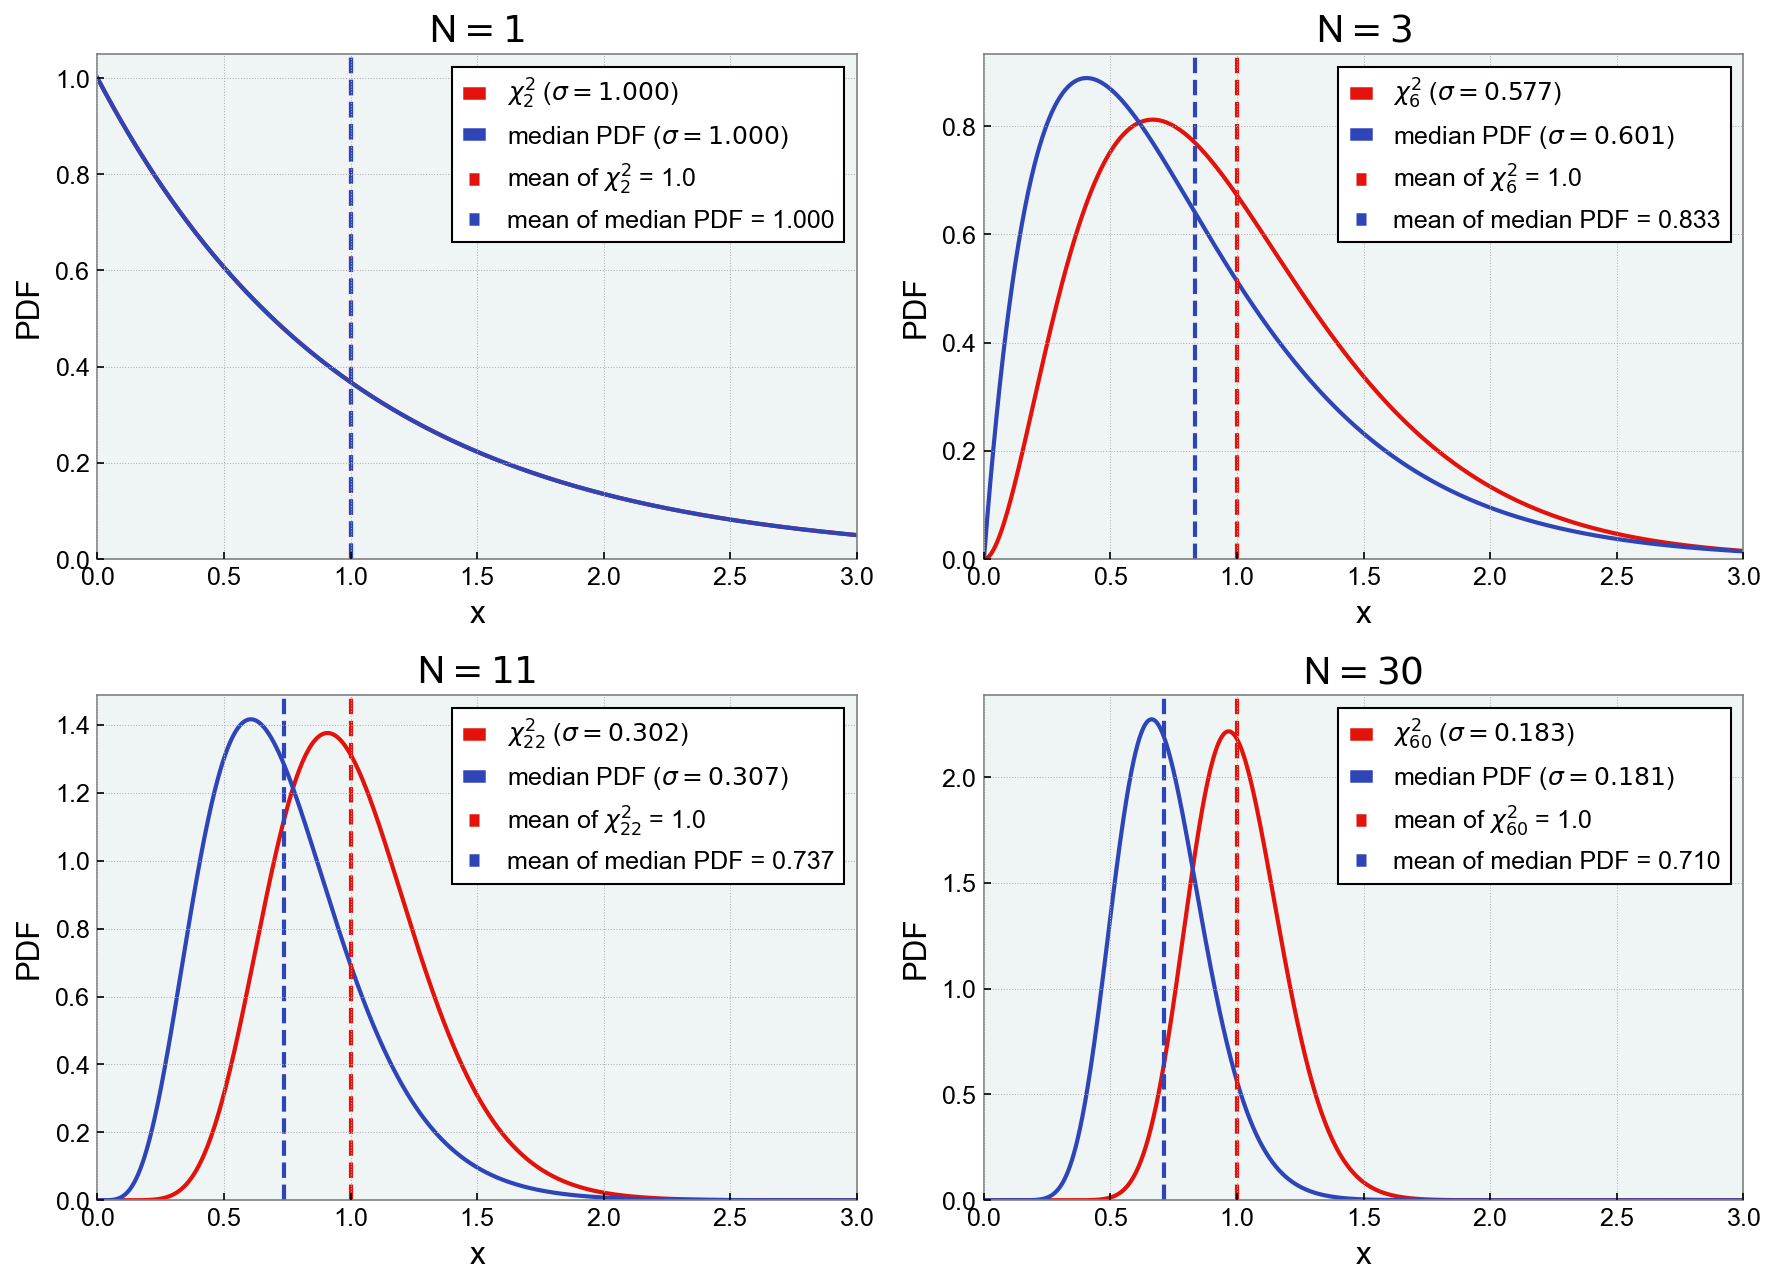

In [29]:
from scipy.integrate import simpson
s     = 1.0
mode  = "unscaled"
N_set = (1, 3, 11, 30)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, N in zip(axes, N_set):
    # ---------------- Compute curves ----------------
    x = np.linspace(0, 50 * s, 20_000)

    # mean PDF
    pdf_mean = pdf(x, N, s, "mean")

    # median PDF
    if mode == "scaled":
        pdf_median = pdf(x, N, s, "median")
        mean_med   = simpson(x * pdf_median, x=x)
        c          = s / mean_med
        pdf_median = median_pdf(x / c, N, s) / c
        mean_med   = simpson(x * pdf_median, x=x)
    else:
        pdf_median = pdf(x, N, s, "median")
        mean_med   = simpson(x * pdf_median, x=x)

    # standard deviations
    σ_mean   = np.sqrt(simpson(x**2 * pdf_mean,   x=x) - s**2)
    σ_median = np.sqrt(simpson(x**2 * pdf_median, x=x) - mean_med**2)

    # ---------------- Plot ----------------
    line_mean,   = ax.plot(x, pdf_mean,   lw=2,
                           label=fr"$\chi^2_{{{2*N}}}$ ($\sigma={σ_mean:.3f}$)", color=econ_red)
    line_median, = ax.plot(x, pdf_median, lw=2,
                           label=fr"median PDF ($\sigma={σ_median:.3f}$)", color=econ_chicago_45)

    ax.set_xlim(0, 3 * s)
    ax.set_ylim(bottom=0)

    if mode == "scaled":
        ax.axvline(s, ls="--", lw=2, label=fr"Mean of PDFs = {s}", color=econ_chicago_45)
    else:
        ax.axvline(s,        ls="--", lw=2, color=econ_red,
                   label=fr"mean of $\chi^2_{{{2*N}}}$ = {s}")
        ax.axvline(mean_med, ls="--", lw=2, color=econ_chicago_45,
                   label=fr"mean of median PDF = {mean_med:.3f}")

    ax.set_xlabel("x")
    ax.set_ylabel("PDF")
    ax.set_title(fr"N$={N}$")
    ax.legend(fontsize="small")

    # labels & title
    ax.set_facecolor(econ_paris_95)
    # ax.legend(facecolor=econ_paris_95,
    #       edgecolor="black",
    #       framealpha=1)
    ax.legend(
          edgecolor="black",
          framealpha=1)
    ax.tick_params(direction="in")
    ax.grid(True, which='both', ls=':', lw=0.5)
    
#fig.patch.set_facecolor(econ_paris_95)
# ---------------- Layout ----------------
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("../report_figs/08_wosa_mean_vs_median_unscaled.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

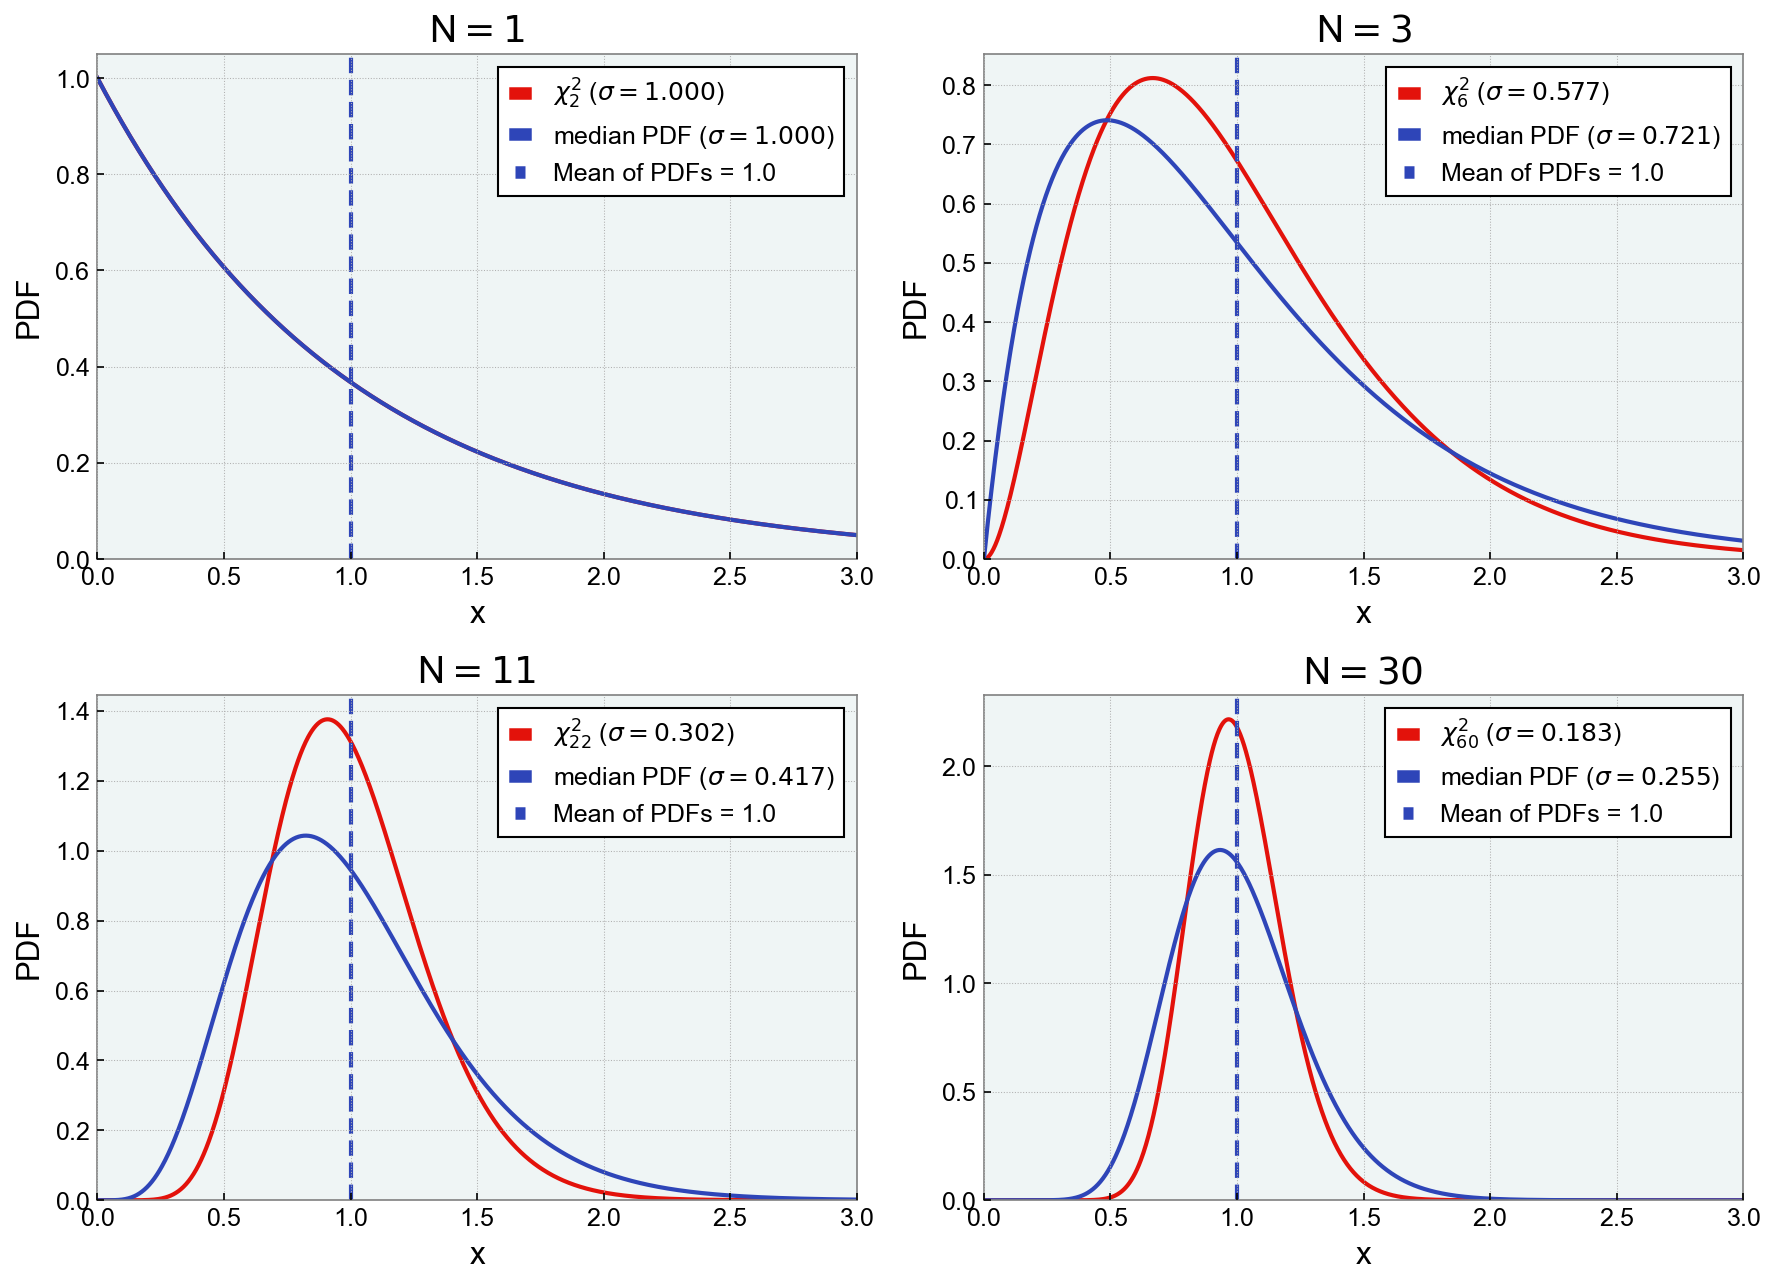

In [30]:
from scipy.integrate import simpson
s     = 1.0
mode  = "scaled"
N_set = (1, 3, 11, 30)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, N in zip(axes, N_set):
    # ---------------- Compute curves ----------------
    x = np.linspace(0, 50 * s, 20_000)

    # mean PDF
    pdf_mean = pdf(x, N, s, "mean")

    # median PDF
    if mode == "scaled":
        pdf_median = pdf(x, N, s, "median")
        mean_med   = simpson(x * pdf_median, x=x)
        c          = s / mean_med
        pdf_median = median_pdf(x / c, N, s) / c
        mean_med   = simpson(x * pdf_median, x=x)
    else:
        pdf_median = pdf(x, N, s, "median")
        mean_med   = simpson(x * pdf_median, x=x)

    # standard deviations
    σ_mean   = np.sqrt(simpson(x**2 * pdf_mean,   x=x) - s**2)
    σ_median = np.sqrt(simpson(x**2 * pdf_median, x=x) - mean_med**2)

    # ---------------- Plot ----------------
    line_mean,   = ax.plot(x, pdf_mean,   lw=2,
                           label=fr"$\chi^2_{{{2*N}}}$ ($\sigma={σ_mean:.3f}$)", color=econ_red)
    line_median, = ax.plot(x, pdf_median, lw=2,
                           label=fr"median PDF ($\sigma={σ_median:.3f}$)", color=econ_chicago_45)

    ax.set_xlim(0, 3 * s)
    ax.set_ylim(bottom=0)

    if mode == "scaled":
        ax.axvline(s, ls="--", lw=2, label=fr"Mean of PDFs = {s}", color=econ_chicago_45)
    else:
        ax.axvline(s,        ls=":", lw=2, color=econ_red,
                   label=fr"Mean₍mean₎ = {s}")
        ax.axvline(mean_med, ls=":", lw=2, color=econ_chicago_45,
                   label=fr"Mean₍median₎ = {mean_med:.3f}")

    ax.set_xlabel("x")
    ax.set_ylabel("PDF")
    ax.set_title(fr"N$={N}$")
    ax.grid(True)
    ax.legend(fontsize="small")

    # labels & title
    ax.set_facecolor(econ_paris_95)
    # ax.legend(facecolor=econ_paris_95,
    #       edgecolor="black",
    #       framealpha=1)
    ax.legend(
          edgecolor="black",
          framealpha=1)
    ax.tick_params(direction="in")
    ax.grid(True, which='both', ls=':', lw=0.5)
    
#fig.patch.set_facecolor(econ_paris_95)
# ---------------- Layout ----------------
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("../report_figs/09_wosa_mean_median_scaled.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


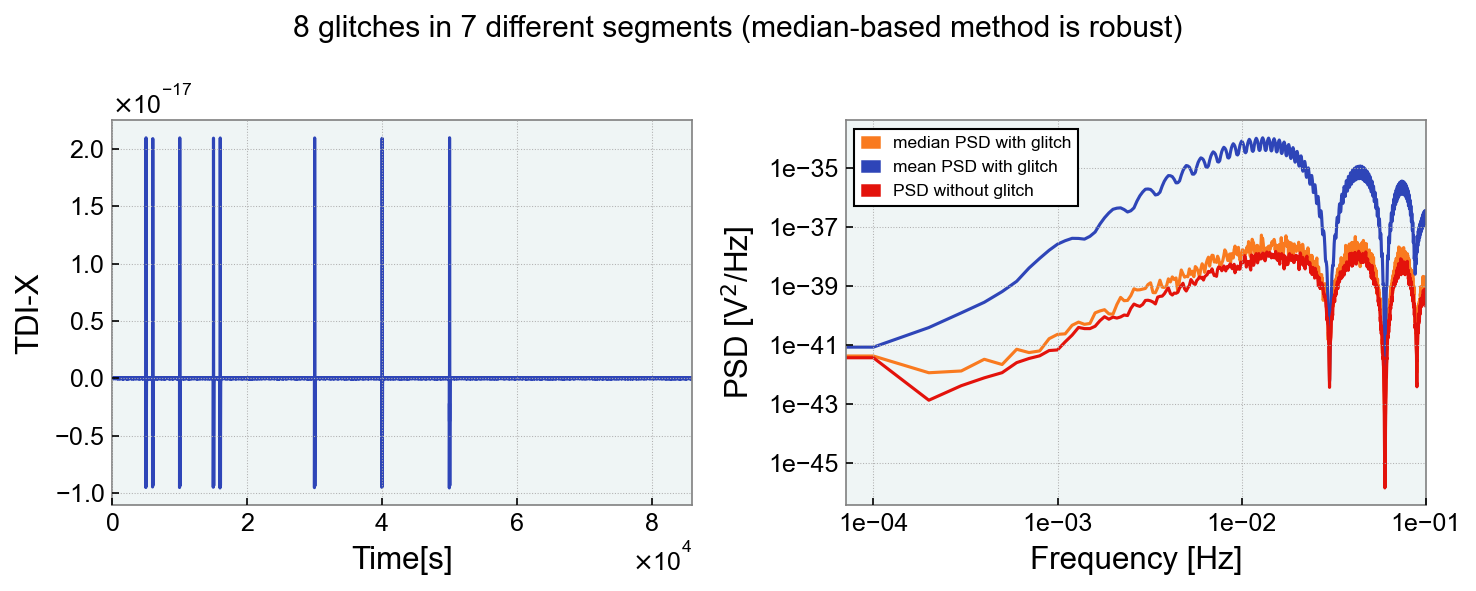

In [41]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_1.h5')
data_orig, fs, t = readTdi(tdi_path)
nperseg = 2000
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

tdi_path = getTdiPath('glitch_7_multiple_7.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# Layout: time series + PSD
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ----- (1) Time-domain plot -----
ax0 = axes[0]
ax0.plot(t, data, color=econ_chicago_45)
ax0.set_xlim(t[0], t[-1])
ax0.set_xlabel("Time[s]")
ax0.set_ylabel("TDI-X")

# ----- (2) PSD(s) -----
ax1 = axes[1]

#  median
ax1.loglog(f_median, psd_median, label="median PSD with glitch", color=econ_singapore_55)

# PSD with glitch
ax1.loglog(f_mean, psd_mean, label="mean PSD with glitch", color=econ_chicago_45)

# PSD without glitch
ax1.loglog(f_mean, psd_orig, label="PSD without glitch", color=econ_red)

# Frequency limits from f_lims = [f_mean[0], f_mean[-1]]
ax1.set_xlim(f_mean[0], f_mean[-1])

ax1.set_xlabel("Frequency [Hz]")
ax1.set_ylabel(r"PSD [V$^2$/Hz]")

#
ax0.tick_params(direction="in")
ax0.set_facecolor(econ_paris_95)

# ax1.legend(facecolor=econ_paris_95,
#           edgecolor="black",
#           framealpha=1)
ax1.legend(
          edgecolor="black",
          framealpha=1,
          fontsize='x-small',
          loc='upper left')
# ax1.legend(
#     loc="center",           # anchor point of the legend box
#     bbox_to_anchor=(0.5, 1.02),   # (x, y) in axes coordinates, (0.5, 1.02) = centered just above
#     ncol=3,                       # number of columns if you want a horizontal legend
#     framealpha=1,
#     edgecolor="black",
#     fontsize="small"
# )
ax1.set_facecolor(econ_paris_95)
ax1.tick_params(direction="in")
ax1.xaxis.set_major_formatter(LogFormatter(base=10))
ax1.yaxis.set_major_formatter(LogFormatter(base=10))
ax1.minorticks_off()
ax0.grid(True, which='both', ls=':', lw=0.5)
ax1.grid(True, which='both', ls=':', lw=0.5)
#fig.patch.set_facecolor(econ_paris_95)
fig.suptitle("8 glitches in 7 different segments (median-based method is robust)")
fig.tight_layout()
plt.savefig("../report_figs/10_eight_glitch_seven_seg.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


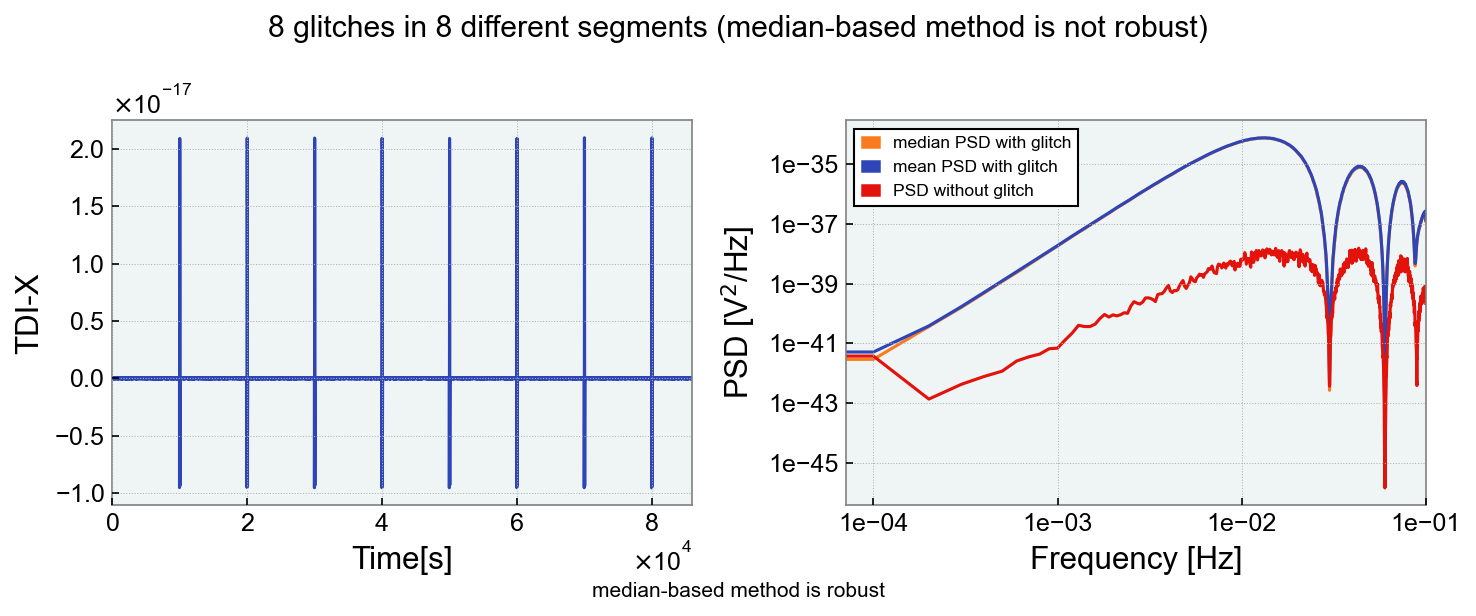

In [43]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_1.h5')
data_orig, fs, t = readTdi(tdi_path)
nperseg = 2000
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

tdi_path = getTdiPath('glitch_7_multiple_2.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# Layout: time series + PSD
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ----- (1) Time-domain plot -----
ax0 = axes[0]
ax0.plot(t, data, color=econ_chicago_45)
ax0.set_xlim(t[0], t[-1])
ax0.set_xlabel("Time[s]")
ax0.set_ylabel("TDI-X")

# ----- (2) PSD(s) -----
ax1 = axes[1]

#  median
ax1.loglog(f_median, psd_median, label="median PSD with glitch", color=econ_singapore_55)

# PSD with glitch
ax1.loglog(f_mean, psd_mean, label="mean PSD with glitch", color=econ_chicago_45)

# PSD without glitch
ax1.loglog(f_mean, psd_orig, label="PSD without glitch", color=econ_red)

# Frequency limits from f_lims = [f_mean[0], f_mean[-1]]
ax1.set_xlim(f_mean[0], f_mean[-1])

ax1.set_xlabel("Frequency [Hz]")
ax1.set_ylabel(r"PSD [V$^2$/Hz]")

#
ax0.tick_params(direction="in")
ax0.set_facecolor(econ_paris_95)

# ax1.legend(facecolor=econ_paris_95,
#           edgecolor="black",
#           framealpha=1)
ax1.legend(
          edgecolor="black",
          framealpha=1,
          fontsize='x-small',
          loc='upper left')
ax1.set_facecolor(econ_paris_95)
ax1.tick_params(direction="in")
ax1.xaxis.set_major_formatter(LogFormatter(base=10))
ax1.yaxis.set_major_formatter(LogFormatter(base=10))
ax1.minorticks_off()
ax0.grid(True, which='both', ls=':', lw=0.5)
ax1.grid(True, which='both', ls=':', lw=0.5)
#fig.patch.set_facecolor(econ_paris_95)
fig.suptitle("8 glitches in 8 different segments (median-based method is not robust)")
fig.text(0.5, 0.01, "median-based method is robust", ha="center", fontsize=10)

fig.tight_layout()
plt.savefig("../report_figs/11_eight_glitch_eight_seg.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

In [33]:
# For debugging fonts
import matplotlib as mpl
import matplotlib.font_manager as fm

print("usetex =", mpl.rcParams["text.usetex"])
print("Current families:", mpl.rcParams["font.family"])
print("Sans list:", mpl.rcParams["font.sans-serif"])

# All font family names Matplotlib knows about:
families = sorted({f.name for f in fm.fontManager.ttflist})
print(len(families), "fonts found")
for name in families:
    print(name)

# Check if a specific font is available and where it lives:
def where(fontname):
    try:
        path = fm.findfont(fontname, fallback_to_default=False)
        print(fontname, "→", path)
    except Exception as e:
        print(fontname, "NOT FOUND:", e)

where("Roboto")
where("Open Sans")
where("DejaVu Sans")   # sanity check

import matplotlib.font_manager as fm

def list_family(family: str):
    fam = family.lower()
    hits = [f for f in fm.fontManager.ttflist if f.name.lower() == fam]
    if not hits:
        print(f"No faces found for family '{family}'. Did you install it?")
        return
    # Sort by style/weight/stretch for readability
    hits = sorted(hits, key=lambda f: (f.style, f.weight, f.stretch, f.fname))
    for f in hits:
        print(f"{f.name:20s}  style={f.style:7s}  weight={f.weight!s:>4s}  "
              f"variant={f.variant:6s}  stretch={f.stretch!s:>4s}  -> {f.fname}")

list_family("Latin Modern")      # or "Open Sans", "DejaVu Sans", etc.

usetex = False
Current families: ['Arial']
Sans list: ['Arial']
309 fonts found
.Aqua Kana
.Keyboard
.New York
.SF Arabic
.SF Arabic Rounded
.SF Compact
.SF Compact Rounded
.SF NS Mono
.SF NS Rounded
.ThonburiUI
Academy Engraved LET
Al Bayan
Al Nile
Al Tarikh
American Typewriter
Andale Mono
Apple Braille
Apple Chancery
Apple SD Gothic Neo
Apple Symbols
AppleGothic
AppleMyungjo
Arial
Arial Black
Arial Hebrew
Arial Narrow
Arial Rounded MT Bold
Arial Unicode MS
Athelas
Avenir
Avenir Next
Avenir Next Condensed
Ayuthaya
Baghdad
Bangla MN
Bangla Sangam MN
Baskerville
Beirut
Big Caslon
Bodoni 72
Bodoni 72 Oldstyle
Bodoni 72 Smallcaps
Bodoni Ornaments
Bradley Hand
Brush Script MT
Chalkboard
Chalkboard SE
Chalkduster
Charter
Cochin
Comic Sans MS
Copperplate
Corsiva Hebrew
Courier
Courier New
DIN Alternate
DIN Condensed
Damascus
DecoType Naskh
DejaVu Sans
DejaVu Sans Display
DejaVu Sans Mono
DejaVu Serif
DejaVu Serif Display
Devanagari MT
Devanagari Sangam MN
Didot
Diwan Kufi
Diwan Thuluth
Euphe